In [17]:
nb_id = 68

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy import constants as C

import sys
sys.path.append('..')

from src.util import DATA_DIR, savefig_base
from src.constants import Z_SUN

plt.style.use('./plotstyle.mplstyle')

In [18]:
FIGURE_FOLDER = Path(f'./output/nb{nb_id}/figures')
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)


def savefig(fig, fname):
    savefig_base(fig, fname, nb_id, FIGURE_FOLDER)

In [19]:
df = pd.read_hdf(DATA_DIR / '00_fiducial_core_props_df_v7.h5')
che = df[df['is_che']].dropna(subset=['r_zams', 'log_t_d']).copy()
print(f'CHE models with valid r_zams and log_t_d: {len(che)}')
print(f'Z bins: {sorted(che.z_key.unique())}')
print(f'Mass range: {che.m_zams.min():.0f} \u2013 {che.m_zams.max():.0f} Msun')

CHE models with valid r_zams and log_t_d: 1683
Z bins: ['0.0200', '0.0400', '0.0800', '0.1000', '0.2000', '0.3000', '0.4000']
Mass range: 30 – 300 Msun


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


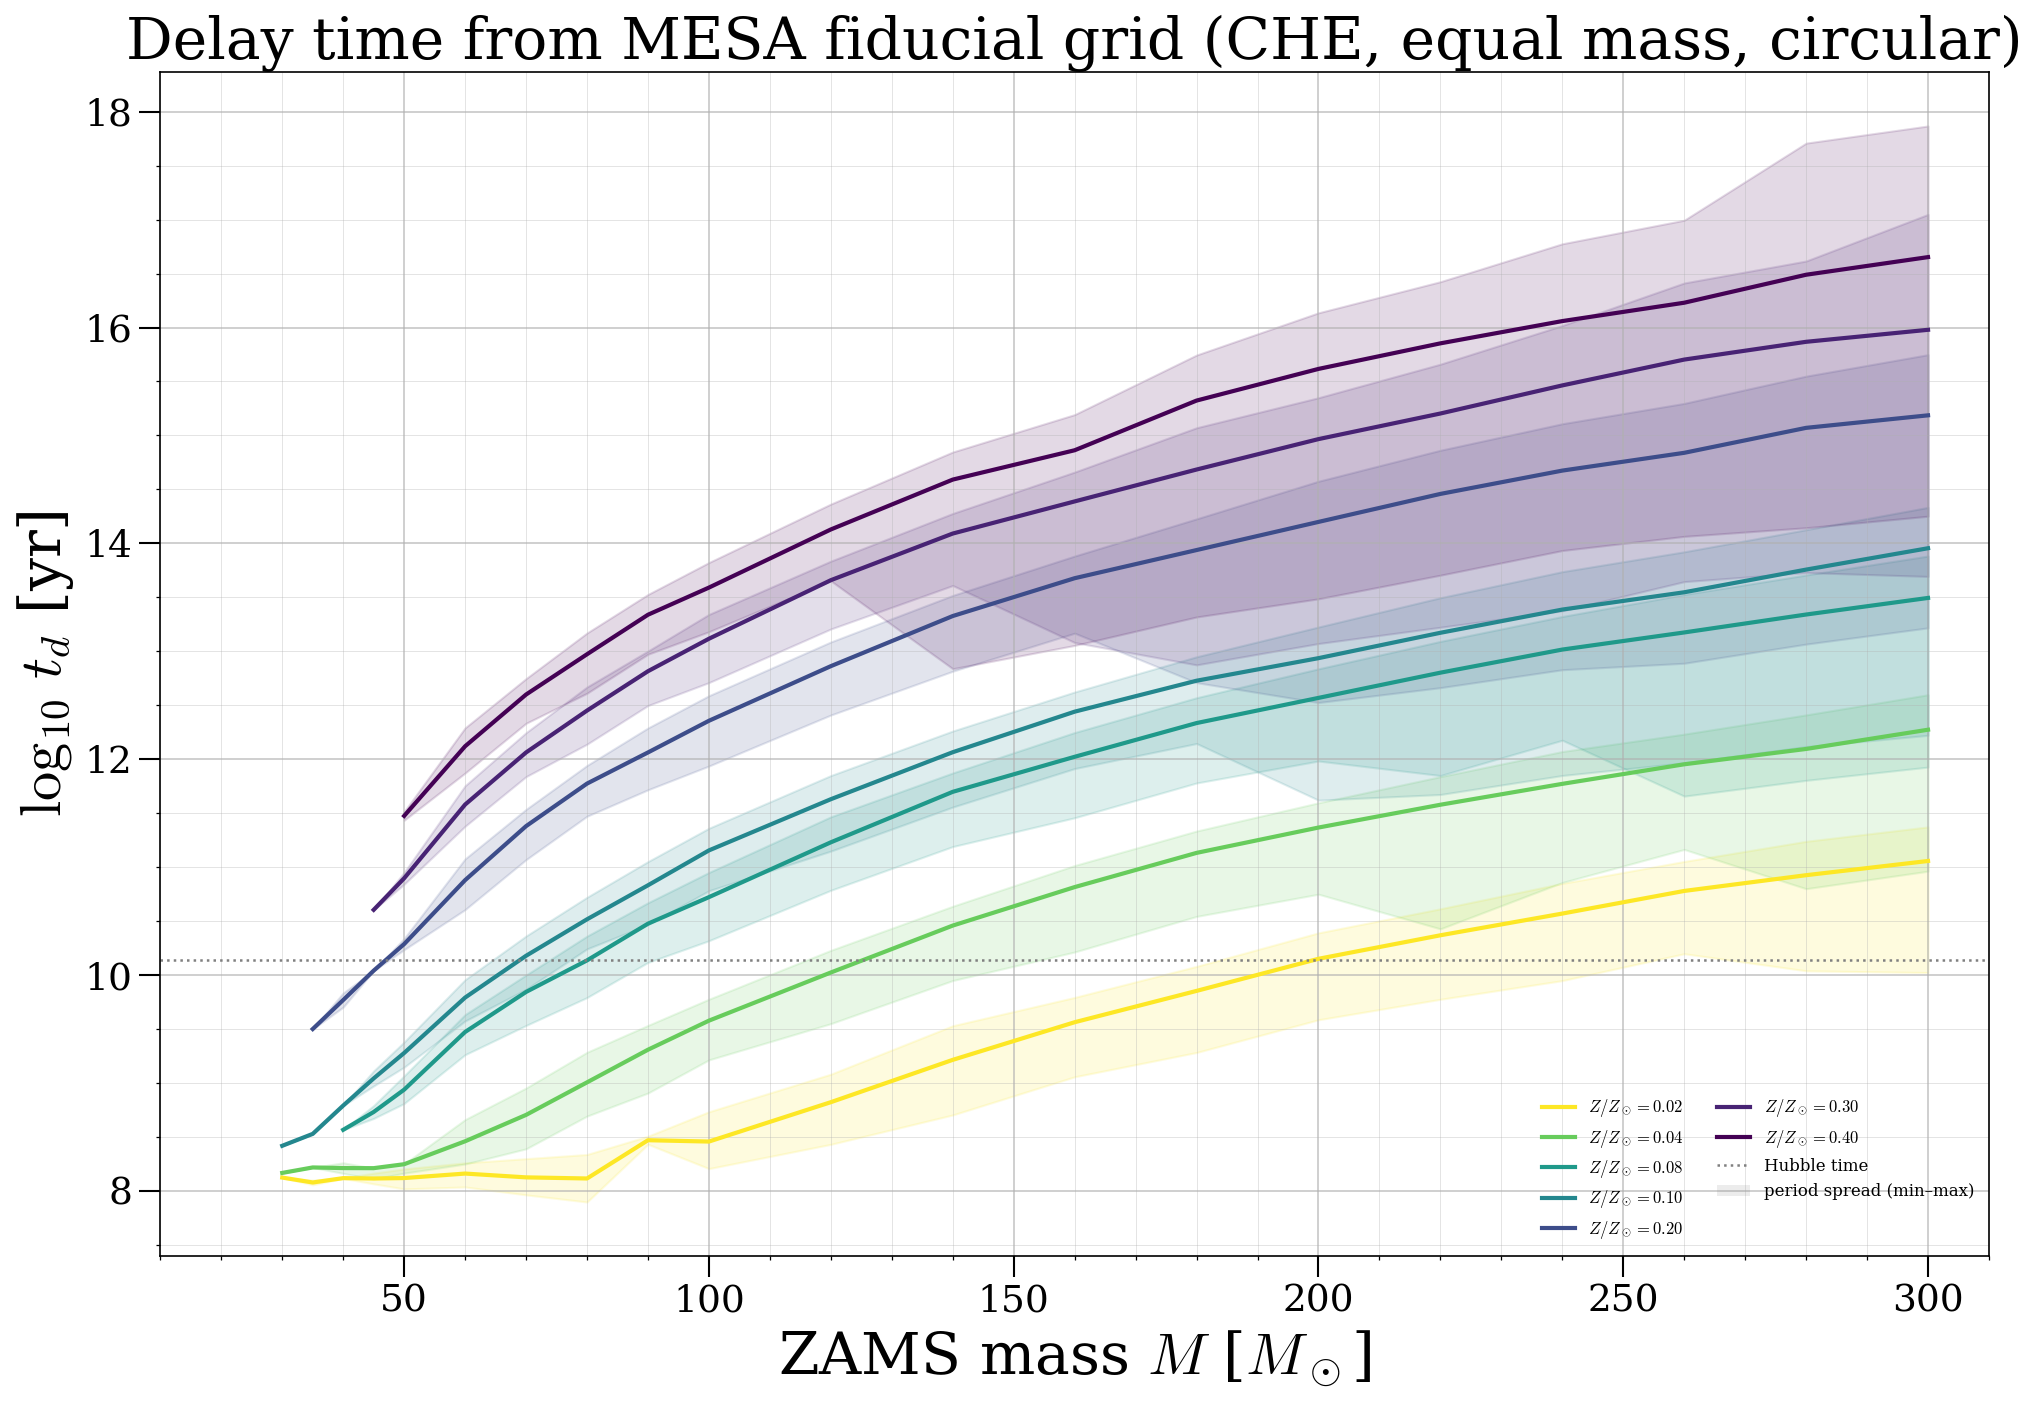

In [20]:
from matplotlib.patches import Patch

z_keys_sorted = sorted(che['z_key'].unique(), key=float)
z_vals = np.array([float(z) for z in z_keys_sorted])

cmap = plt.cm.viridis_r
norm = LogNorm(vmin=z_vals.min(), vmax=z_vals.max())

fig, ax = plt.subplots(figsize=(14, 10), dpi=150)

for z_key in z_keys_sorted:
    z_val = float(z_key)
    sub = che[che['z_key'] == z_key].sort_values('m_zams')
    color = cmap(norm(z_val))

    med = sub.groupby('m_zams')['log_t_d'].agg(['median', 'min', 'max'])
    masses = med.index.values

    ax.plot(masses, med['median'], lw=2, color=color,
            label=rf'$Z/Z_\odot = {z_val:.2f}$')
    ax.fill_between(masses, med['min'], med['max'], alpha=0.15, color=color)

ax.axhline(np.log10(1.377e10), ls=':', lw=1.2, color='gray', label='Hubble time')

handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor='gray', alpha=0.15, edgecolor='none'))
labels.append('period spread (min–max)')
ax.legend(handles, labels, fontsize=8, loc='lower right', ncol=2, frameon=False)

ax.set_xlim(10, 310)
ax.set_xlabel(r'ZAMS mass $M$ [$M_\odot$]')
ax.set_ylabel(r'$\log_{10}\, t_d$ [yr]')
ax.set_title(r'Delay time from MESA fiducial grid (CHE, equal mass, circular)')
ax.minorticks_on()
ax.grid(True, which='major', lw=0.8, alpha=0.7)
ax.grid(True, which='minor', lw=0.4, alpha=0.4)

fig.tight_layout()
savefig(fig, 't_delay_vs_mass_fiducial')

 z_val  m_es    m_peak  pinned  m_peak_over_m_es
  0.02  30.0 35.023005   False          1.167433
  0.04  30.0 45.015003   False          1.500500
  0.08  25.0 57.126425   False          2.285057
  0.10  30.0 57.113423   False          1.903781
  0.20  35.0 60.021004   False          1.714886
  0.30  35.0 60.021004   False          1.714886
  0.40  50.0 60.002000   False          1.200040


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


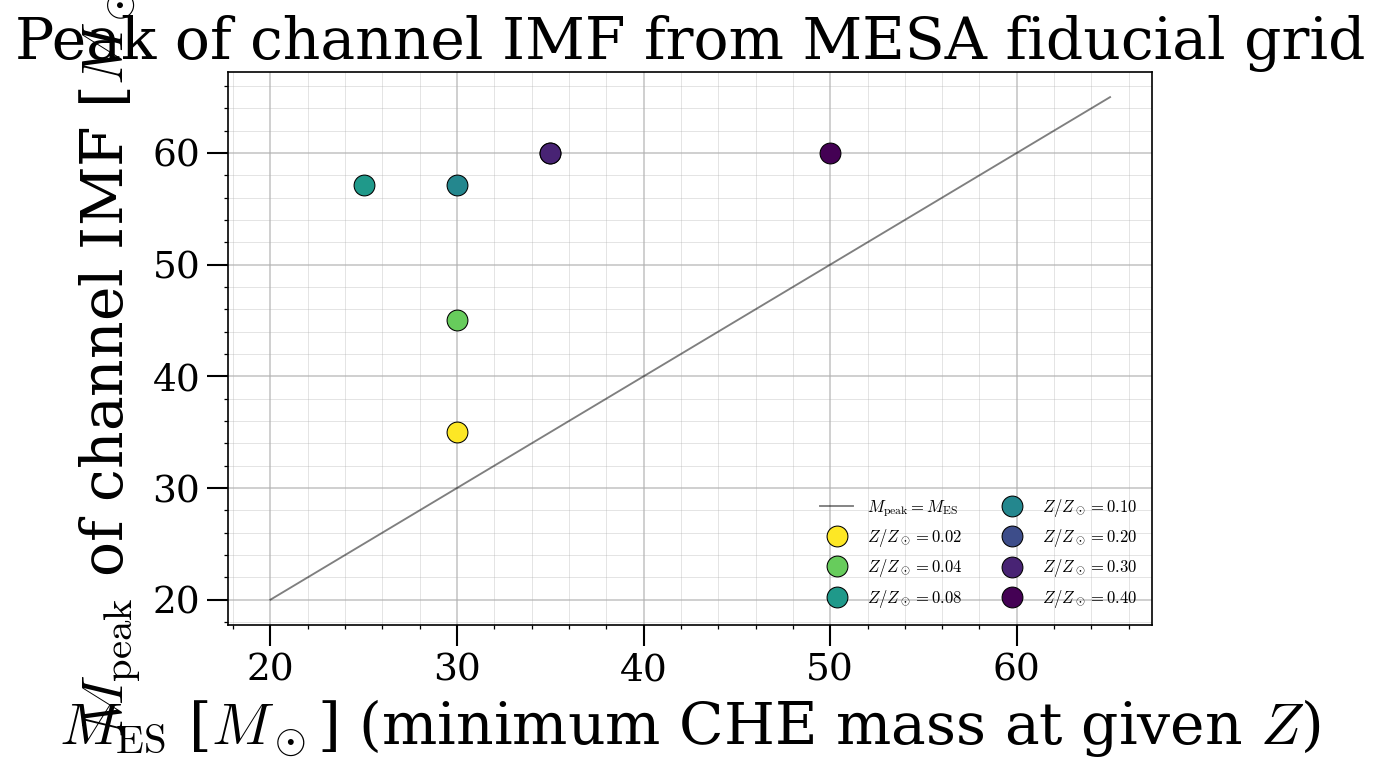

In [26]:
from scipy.interpolate import interp1d

GAMMA = 2.35
P_TOT = 1e4  # d, upper edge of the Öpik period distribution

# All CHE-flagged models (including crashes) to get the true M_ES
che_all = df[df['is_che'] == True]

peak_data = []
for z_key in z_keys_sorted:
    # True M_ES from all CHE models (including crashed)
    m_es = che_all[che_all['z_key'] == z_key]['m_zams'].min()

    # Window boundaries from valid models only
    sub = che[che['z_key'] == z_key]
    window = sub.groupby('m_zams')['p_spin_zams'].agg(p_min='min', p_max='max')
    masses = window.index.values

    if len(masses) < 3:
        continue

    pmin_f = interp1d(masses, window['p_min'], kind='linear',
                      bounds_error=False, fill_value=np.nan)
    pmax_f = interp1d(masses, window['p_max'], kind='linear',
                      bounds_error=False, fill_value=np.nan)

    m_fine = np.linspace(m_es, masses.max(), 5000)
    pmin = pmin_f(m_fine)
    pmax = pmax_f(m_fine)

    with np.errstate(invalid='ignore', divide='ignore'):
        wfrac = np.log(pmax / pmin) / np.log(P_TOT / pmin)
    wfrac = np.where(np.isfinite(wfrac) & (wfrac > 0), wfrac, 0.0)

    xi = m_fine**(-GAMMA) * wfrac
    if xi.max() > 0:
        i_peak = np.argmax(xi)
        m_peak = m_fine[i_peak]
        pinned = i_peak >= len(m_fine) - 2
    else:
        m_peak = np.nan
        pinned = False

    peak_data.append(dict(z_val=float(z_key), m_es=m_es, m_peak=m_peak, pinned=pinned))

peak_df = pd.DataFrame(peak_data)
peak_df['m_peak_over_m_es'] = peak_df['m_peak'] / peak_df['m_es']
print(peak_df.to_string(index=False))

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5.8), dpi=150)

ax.plot([20, 65], [20, 65], 'k-', lw=0.9, alpha=0.5,
        label=r'$M_\mathrm{peak} = M_\mathrm{ES}$')

for _, row in peak_df.iterrows():
    color = cmap(norm(row['z_val']))
    marker = 's' if row['pinned'] else 'o'
    ax.plot(row['m_es'], row['m_peak'], marker, ms=10, color=color,
            markeredgecolor='k', markeredgewidth=0.5, zorder=5,
            label=rf'$Z/Z_\odot = {row["z_val"]:.2f}$')

ax.set_xlabel(r'$M_\mathrm{ES}$ [$M_\odot$] (minimum CHE mass at given $Z$)')
ax.set_ylabel(r'$M_\mathrm{peak}$ of channel IMF [$M_\odot$]')
ax.set_title(r'Peak of channel IMF from MESA fiducial grid')
ax.legend(fontsize=8, frameon=False, ncol=2, loc='lower right')
ax.minorticks_on()
ax.grid(True, which='major', lw=0.8, alpha=0.7)
ax.grid(True, which='minor', lw=0.4, alpha=0.4)

fig.tight_layout()
savefig(fig, 'channel_imf_peak_fiducial')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


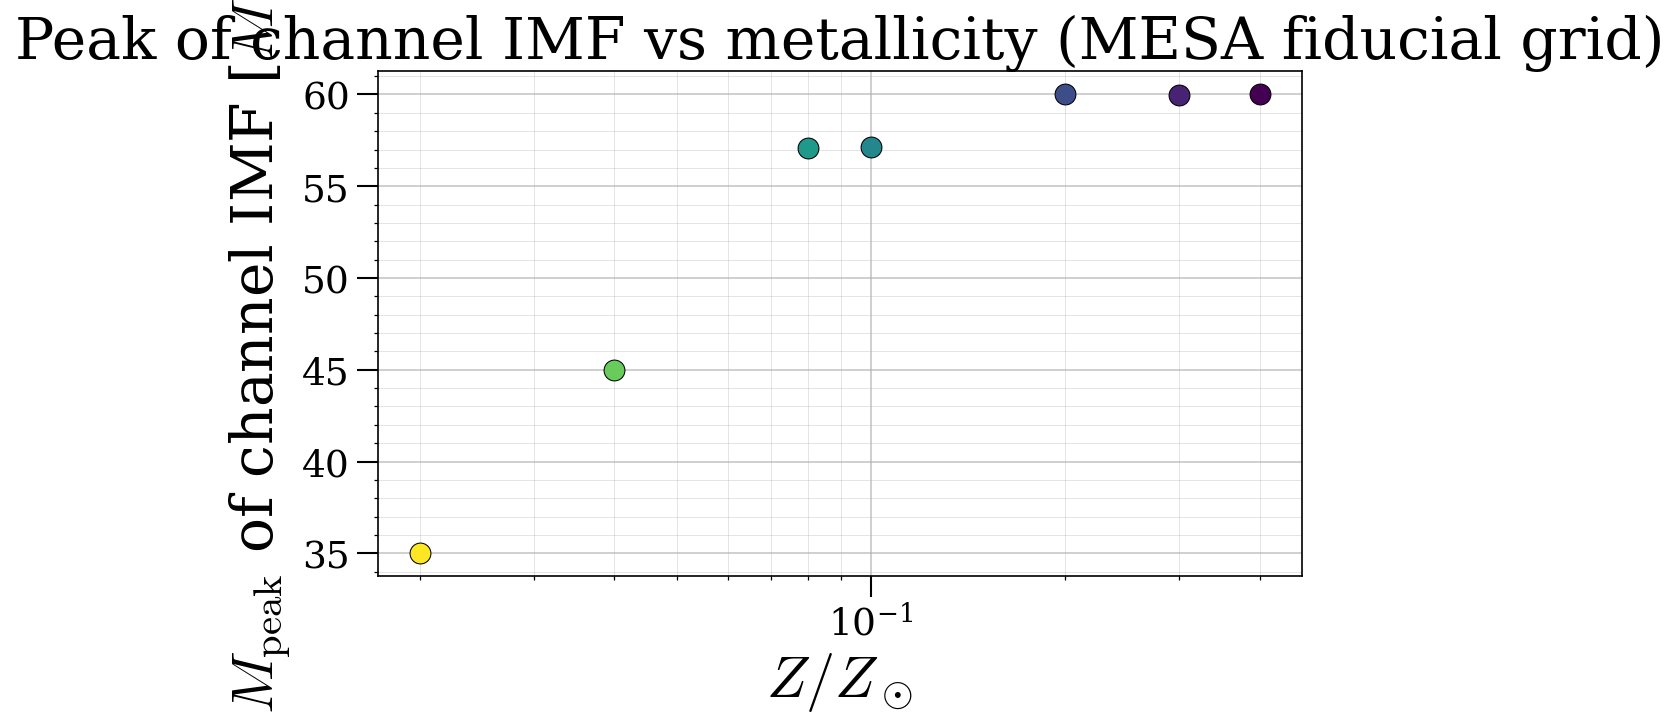

In [22]:
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=150)

for _, row in peak_df.iterrows():
    color = cmap(norm(row['z_val']))
    marker = 's' if row['pinned'] else 'o'
    ax.plot(row['z_val'], row['m_peak'], marker, ms=10, color=color,
            markeredgecolor='k', markeredgewidth=0.5, zorder=5)

ax.set_xscale('log')
ax.set_xlabel(r'$Z / Z_\odot$')
ax.set_ylabel(r'$M_\mathrm{peak}$ of channel IMF [$M_\odot$]')
ax.set_title('Peak of channel IMF vs metallicity (MESA fiducial grid)')
ax.minorticks_on()
ax.grid(True, which='major', lw=0.8, alpha=0.7)
ax.grid(True, which='minor', lw=0.4, alpha=0.4)

fig.tight_layout()
savefig(fig, 'channel_imf_peak_vs_z')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


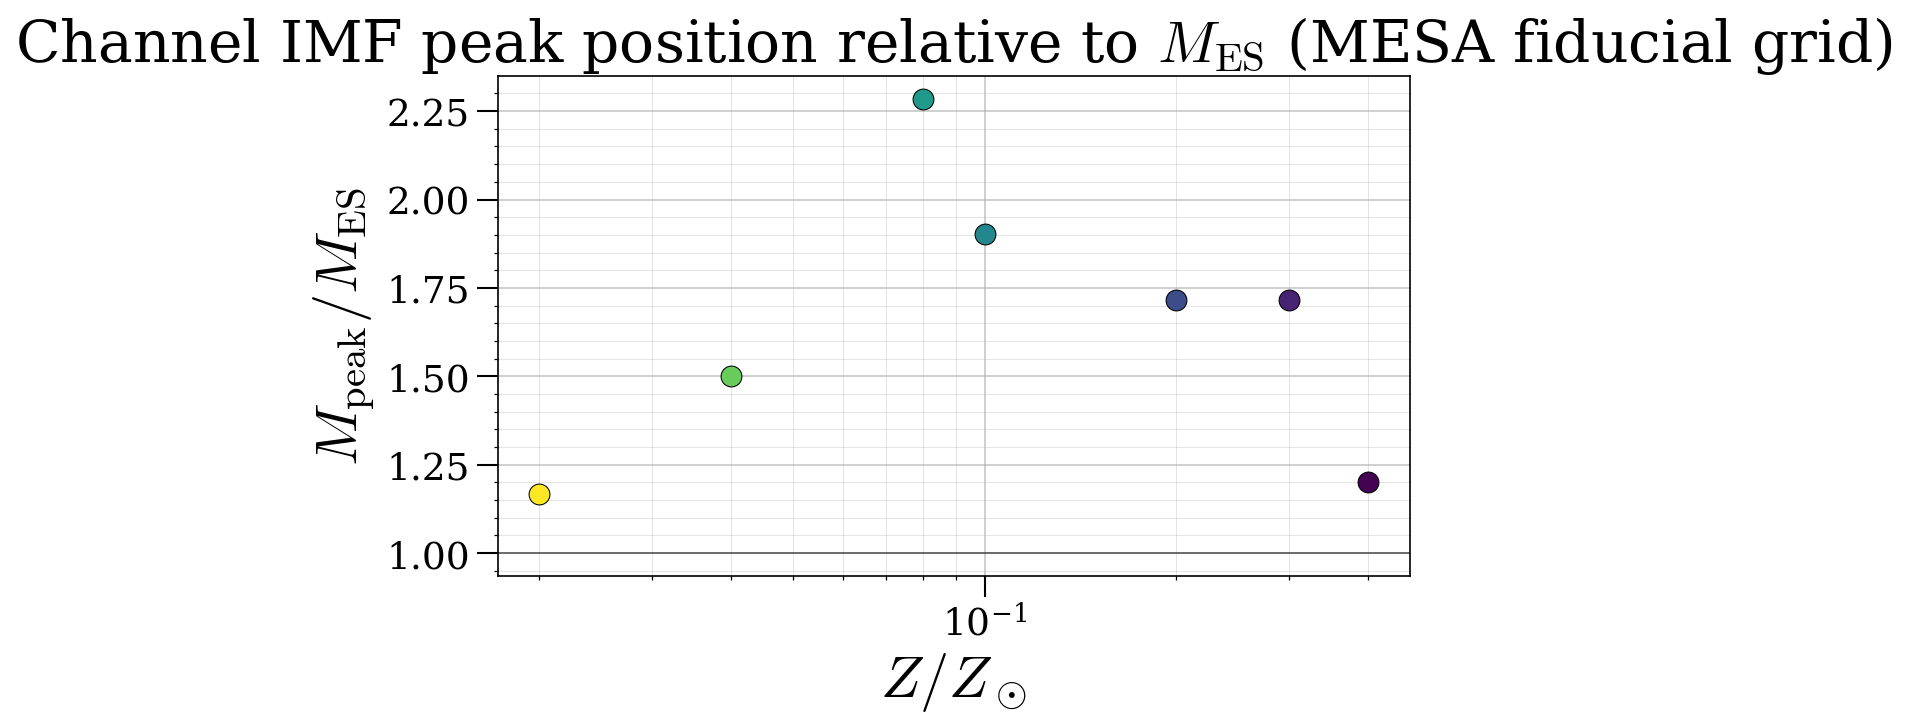

In [24]:
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=150)

for _, row in peak_df.iterrows():
    color = cmap(norm(row['z_val']))
    marker = 's' if row['pinned'] else 'o'
    ax.plot(row['z_val'], row['m_peak_over_m_es'], marker, ms=10, color=color,
            markeredgecolor='k', markeredgewidth=0.5, zorder=5)

ax.axhline(1, ls='-', lw=0.9, color='k', alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel(r'$Z / Z_\odot$')
ax.set_ylabel(r'$M_\mathrm{peak} / M_\mathrm{ES}$')
ax.set_title(r'Channel IMF peak position relative to $M_\mathrm{ES}$ (MESA fiducial grid)')
ax.minorticks_on()
ax.grid(True, which='major', lw=0.8, alpha=0.7)
ax.grid(True, which='minor', lw=0.4, alpha=0.4)

fig.tight_layout()
savefig(fig, 'channel_imf_peak_ratio_vs_z')